In [1]:
!nvidia-smi

Mon Jan  9 00:40:15 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   57C    P0    27W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# 1. imgaug

In [113]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import imgaug as ia
import imgaug.augmenters as iaa
ia.seed(1)

In [114]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Crop(percent=(0, 0.1)), # random crops
    # Small gaussian blur with random sigma between 0 and 0.5.
    # But we only blur about 50% of all images.
    iaa.Sometimes(
        0.5,
        iaa.GaussianBlur(sigma=(0, 0.5))
    ),
    # Strengthen or weaken the contrast in each image.
    iaa.LinearContrast((0.75, 1.5)),
    # Add gaussian noise.
    # For 50% of all images, we sample the noise once per pixel.
    # For the other 50% of all images, we sample the noise per pixel AND
    # channel. This can change the color (not only brightness) of the
    # pixels.
    iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05*255), per_channel=0.5),
    # Make some images brighter and some darker.
    # In 20% of all cases, we sample the multiplier once per channel,
    # which can end up changing the color of the images.
    iaa.Multiply((0.8, 1.2), per_channel=0.01),
    # Apply affine transformations to each image.
    # Scale/zoom them, translate/move them, rotate them and shear them.
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        rotate=(-25, 25),
        shear=(-8, 8)
    )
], random_order=True) # apply augmenters in random order

In [5]:
labels = ['chalk','charcoal','sage','sand','sky']
N = 1000

if not os.path.isdir(f'train/'):
        os.mkdir(f'train/')
        
for label in labels:
    img = cv2.imread(f'{label}_0.jpg')
    dim=227
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    print(img.shape)

    # The array has shape (32, 64, 64, 3) and dtype uint8. example: ia.quokka(size=(64, 64))
    images = np.array([ img for _ in range(N)],dtype=np.uint8)

    images_aug = seq(images=images)

    if not os.path.isdir(f'train/{label}'):
        os.mkdir(f'train/{label}')

    for i in range(N):
        cv2.imwrite(f'train/{label}/{label}_{i}.jpg',images_aug[i])

(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)


In [7]:
labels = ['chalk','charcoal','sage','sand','sky']
N = 1000

if not os.path.isdir(f'test/'):
        os.mkdir(f'test/')
        
for label in labels:
    img = cv2.imread(f'{label}_0.jpg')
    dim=227
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    print(img.shape)

    # The array has shape (32, 64, 64, 3) and dtype uint8. example: ia.quokka(size=(64, 64))
    images = np.array([ img for _ in range(N)],dtype=np.uint8)

    images_aug = seq(images=images)

    if not os.path.isdir(f'test/{label}'):
        os.mkdir(f'test/{label}')

    for i in range(N):
        cv2.imwrite(f'test/{label}/{label}_{i}.jpg',images_aug[i])

(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)


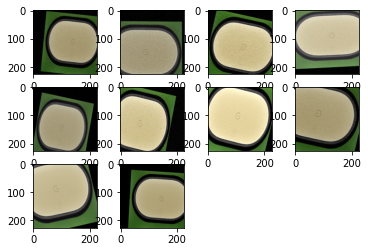

In [8]:
num = 10
col=4
imgs = list(np.random.choice(len(images_aug),num))
for i in range(num):
    plt.subplot(num/col if num%col==0 else int(num/col)+1,col,i+1)
    plt.imshow(images_aug[imgs[i]])

# 2. color classification

# 2.1 ColorNet

In [9]:
from keras.models import Sequential,Model,load_model
from keras.optimizers import SGD
from keras.layers import Concatenate, BatchNormalization, Lambda, Input, Dense, Convolution2D, MaxPooling2D, AveragePooling2D, ZeroPadding2D, Dropout, Flatten, Reshape, Activation
# from keras.layers.merge import Concatenate
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint
import numpy as np
import keras.backend as K

In [10]:
def color_net(num_classes):
    # placeholder for input image
    input_image = Input(shape=(227,227,3))
    # ============================================= TOP BRANCH ===================================================
    # first top convolution layer
    top_conv1 = Convolution2D(filters=48,kernel_size=(11,11),strides=(4,4),
                              input_shape=(224,224,3),activation='relu')(input_image)
    top_conv1 = BatchNormalization()(top_conv1)
    top_conv1 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(top_conv1)

    # second top convolution layer
    # split feature map by half
    top_top_conv2 = Lambda(lambda x : x[:,:,:,:24])(top_conv1)
    top_bot_conv2 = Lambda(lambda x : x[:,:,:,24:])(top_conv1)

    top_top_conv2 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(top_top_conv2)
    top_top_conv2 = BatchNormalization()(top_top_conv2)
    top_top_conv2 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(top_top_conv2)

    top_bot_conv2 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(top_bot_conv2)
    top_bot_conv2 = BatchNormalization()(top_bot_conv2)
    top_bot_conv2 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(top_bot_conv2)

    # third top convolution layer
    # concat 2 feature map
    top_conv3 = Concatenate()([top_top_conv2,top_bot_conv2])
    top_conv3 = Convolution2D(filters=192,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(top_conv3)

    # fourth top convolution layer
    # split feature map by half
    top_top_conv4 = Lambda(lambda x : x[:,:,:,:96])(top_conv3)
    top_bot_conv4 = Lambda(lambda x : x[:,:,:,96:])(top_conv3)

    top_top_conv4 = Convolution2D(filters=96,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(top_top_conv4)
    top_bot_conv4 = Convolution2D(filters=96,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(top_bot_conv4)

    # fifth top convolution layer
    top_top_conv5 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(top_top_conv4)
    top_top_conv5 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(top_top_conv5) 

    top_bot_conv5 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(top_bot_conv4)
    top_bot_conv5 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(top_bot_conv5)

    # ============================================= TOP BOTTOM ===================================================
    # first bottom convolution layer
    bottom_conv1 = Convolution2D(filters=48,kernel_size=(11,11),strides=(4,4),
                              input_shape=(227,227,3),activation='relu')(input_image)
    bottom_conv1 = BatchNormalization()(bottom_conv1)
    bottom_conv1 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(bottom_conv1)

    # second bottom convolution layer
    # split feature map by half
    bottom_top_conv2 = Lambda(lambda x : x[:,:,:,:24])(bottom_conv1)
    bottom_bot_conv2 = Lambda(lambda x : x[:,:,:,24:])(bottom_conv1)

    bottom_top_conv2 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(bottom_top_conv2)
    bottom_top_conv2 = BatchNormalization()(bottom_top_conv2)
    bottom_top_conv2 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(bottom_top_conv2)

    bottom_bot_conv2 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(bottom_bot_conv2)
    bottom_bot_conv2 = BatchNormalization()(bottom_bot_conv2)
    bottom_bot_conv2 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(bottom_bot_conv2)

    # third bottom convolution layer
    # concat 2 feature map
    bottom_conv3 = Concatenate()([bottom_top_conv2,bottom_bot_conv2])
    bottom_conv3 = Convolution2D(filters=192,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(bottom_conv3)

    # fourth bottom convolution layer
    # split feature map by half
    bottom_top_conv4 = Lambda(lambda x : x[:,:,:,:96])(bottom_conv3)
    bottom_bot_conv4 = Lambda(lambda x : x[:,:,:,96:])(bottom_conv3)

    bottom_top_conv4 = Convolution2D(filters=96,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(bottom_top_conv4)
    bottom_bot_conv4 = Convolution2D(filters=96,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(bottom_bot_conv4)

    # fifth bottom convolution layer
    bottom_top_conv5 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(bottom_top_conv4)
    bottom_top_conv5 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(bottom_top_conv5) 

    bottom_bot_conv5 = Convolution2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same')(bottom_bot_conv4)
    bottom_bot_conv5 = MaxPooling2D(pool_size=(3,3),strides=(2,2))(bottom_bot_conv5)

    # ======================================== CONCATENATE TOP AND BOTTOM BRANCH =================================
    conv_output = Concatenate()([top_top_conv5,top_bot_conv5,bottom_top_conv5,bottom_bot_conv5])

    # Flatten
    flatten = Flatten()(conv_output)

    # Fully-connected layer
    FC_1 = Dense(units=4096, activation='relu')(flatten)
    FC_1 = Dropout(0.6)(FC_1)
    FC_2 = Dense(units=4096, activation='relu')(FC_1)
    FC_2 = Dropout(0.6)(FC_2)
    output = Dense(units=num_classes, activation='softmax')(FC_2)
    
    model = Model(inputs=input_image,outputs=output)
    sgd = SGD(lr=1e-3, decay=1e-6, momentum=0.9, nesterov=True)
    # sgd = SGD(lr=0.01, momentum=0.9, decay=0.0005, nesterov=True)
    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [11]:
img_rows , img_cols = 227,227
num_classes = 5
batch_size = 32

# initialise model
model = color_net(num_classes)

# initialize checkpoint
filepath = 'color_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.3,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

/usr/local/lib/python3.8/dist-packages/keras/optimizers/optimizer_v2/gradient_descent.py:108: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


In [ ]:
model.summary()

        main_directory/
        ...class_a/
        ......a_image_1.jpg
        ......a_image_2.jpg
        ...class_b/
        ......b_image_1.jpg
        ......b_image_2.jpg

In [12]:
training_set = train_datagen.flow_from_directory(
            'train/',
            target_size=(img_rows, img_cols),
            batch_size=batch_size,
            class_mode='categorical')

Found 50000 images belonging to 5 classes.


In [13]:
test_set = test_datagen.flow_from_directory(
            'test/',
            target_size=(img_rows, img_cols),
            batch_size=batch_size,
            class_mode='categorical')

Found 5000 images belonging to 5 classes.


In [14]:
nb_epoch = 8
steps_per_epoch= 1000
validation_steps= 100

model.fit_generator(
        training_set,
        steps_per_epoch= steps_per_epoch,
        epochs=nb_epoch,
        validation_data=test_set,
        validation_steps=validation_steps,
        callbacks=callbacks_list)

<ipython-input-14-4ce3eb323a3c>:5: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(


Epoch 1/8
1000/1000 [==============================] - ETA: 0s - loss: 0.1021 - accuracy: 0.9659

1000/1000 [==============================] - 399s 389ms/step - loss: 0.1021 - accuracy: 0.9659 - val_loss: 0.0252 - val_accuracy: 0.9969
Epoch 2/8
1000/1000 [==============================] - ETA: 0s - loss: 0.0207 - accuracy: 0.9960

1000/1000 [==============================] - 392s 392ms/step - loss: 0.0207 - accuracy: 0.9960 - val_loss: 0.0334 - val_accuracy: 0.9966
Epoch 3/8
1000/1000 [==============================] - ETA: 0s - loss: 0.0265 - accuracy: 0.9939

1000/1000 [==============================] - 368s 368ms/step - loss: 0.0265 - accuracy: 0.9939 - val_loss: 0.0162 - val_accuracy: 0.9972
Epoch 4/8
1000/1000 [==============================] - ETA: 0s - loss: 0.0201 - accuracy: 0.9953

1000/1000 [==============================] - 364s 364ms/step - loss: 0.0201 - accuracy: 0.9953 - val_loss: 0.0463 - val_accuracy: 0.9906
Epoch 5/8
1000/1000 [==============================] - ETA: 0s - loss: 0.0135 - accuracy: 0.9970

1000/1000 [==============================] - 365s 365ms/step - loss: 0.0135 - accuracy: 0.9970 - val_loss: 0.0099 - val_accuracy: 0.9975
Epoch 6/8
1000/1000 [==============================] - ETA: 0s - loss: 0.0128 - accuracy: 0.9972

1000/1000 [==============================] - 367s 367ms/step - loss: 0.0128 - accuracy: 0.9972 - val_loss: 0.0152 - val_accuracy: 0.9972
Epoch 7/8
1000/1000 [==============================] - ETA: 0s - loss: 0.0101 - accuracy: 0.9976

1000/1000 [==============================] - 366s 366ms/step - loss: 0.0101 - accuracy: 0.9976 - val_loss: 0.0121 - val_accuracy: 0.9972
Epoch 8/8
1000/1000 [==============================] - ETA: 0s - loss: 0.0108 - accuracy: 0.9977

1000/1000 [==============================] - 361s 361ms/step - loss: 0.0108 - accuracy: 0.9977 - val_loss: 0.0090 - val_accuracy: 0.9978


# evaluate

In [17]:
model.save('color_model.h5')

# predict

(1, 227, 227, 3)
KerasTensor(type_spec=TensorSpec(shape=(None, 227, 227, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
1/1 [==============================] - 0s 16ms/step
[[1. 0. 0. 0. 0.]]


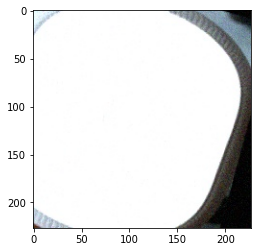

In [44]:
dim=227
label = 'chalk'
path = 'test'
# read image
imgs = os.listdir(os.path.join(path,label))
img = cv2.imread(os.path.join(path,label,random.choice(imgs)))
# resize image
img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
plt.imshow(img)
# reshape image
img = np.array([img])
print(img.shape)
print(model.input)
print(model.predict(img))

(1, 227, 227, 3)
KerasTensor(type_spec=TensorSpec(shape=(None, 227, 227, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
1/1 [==============================] - 0s 17ms/step
[[0. 0. 0. 1. 0.]]


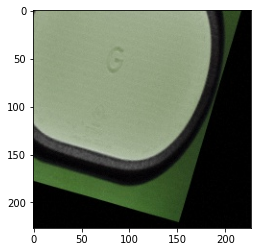

In [43]:
dim=227
label = 'sage'
path = 'test'
# read image
imgs = os.listdir(os.path.join(path,label))
img = cv2.imread(os.path.join(path,label,random.choice(imgs)))
# resize image
img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
plt.imshow(img)
# reshape image
img = np.array([img])
print(img.shape)
print(model.input)
print(model.predict(img))

(1, 227, 227, 3)
KerasTensor(type_spec=TensorSpec(shape=(None, 227, 227, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
1/1 [==============================] - 0s 17ms/step
[[0. 0. 0. 1. 0.]]


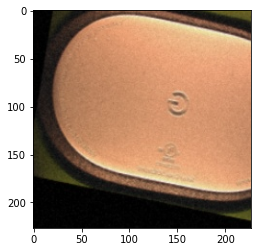

In [41]:
dim=227
label = 'charcoal'
path = 'test'
# read image
imgs = os.listdir(os.path.join(path,label))
img = cv2.imread(os.path.join(path,label,random.choice(imgs)))
# resize image
img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
plt.imshow(img)
# reshape image
img = np.array([img])
print(img.shape)
print(model.input)

print(model.predict(img))

(1, 227, 227, 3)
KerasTensor(type_spec=TensorSpec(shape=(None, 227, 227, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
1/1 [==============================] - 0s 28ms/step
[[1. 0. 0. 0. 0.]]


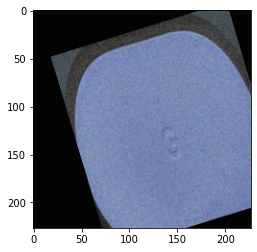

In [45]:
dim=227
label = 'sand'
path = 'test'
# read image
imgs = os.listdir(os.path.join(path,label))
img = cv2.imread(os.path.join(path,label,random.choice(imgs)))
# resize image
img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
plt.imshow(img)
# reshape image
img = np.array([img])
print(img.shape)
print(model.input)
print(model.predict(img))

(1, 227, 227, 3)
KerasTensor(type_spec=TensorSpec(shape=(None, 227, 227, 3), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
1/1 [==============================] - 0s 17ms/step
[[0. 0. 0. 1. 0.]]


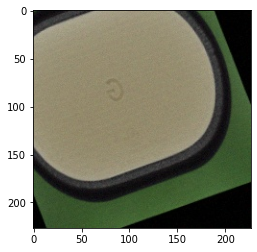

In [46]:

dim=227
label = 'sky'
path = 'test'
# read image
imgs = os.listdir(os.path.join(path,label))
img = cv2.imread(os.path.join(path,label,random.choice(imgs)))
# resize image
img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
plt.imshow(img)
# reshape image
img = np.array([img])
print(img.shape)
print(model.input)
print(model.predict(img))

# 2.2 SVM

[link](https://www.kaggle.com/code/ashutoshvarma/image-classification-using-svm-92-accuracy)

In [153]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import imgaug as ia
import imgaug.augmenters as iaa
import pickle
ia.seed(1)

In [154]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Crop(percent=(0, 0.1)), # random crops
    # Small gaussian blur with random sigma between 0 and 0.5.
    # But we only blur about 50% of all images.
    iaa.Sometimes(
        0.5,
        iaa.GaussianBlur(sigma=(0, 0.5))
    ),
    # Strengthen or weaken the contrast in each image.
    iaa.LinearContrast((0.75, 1.5)),
    # Add gaussian noise.
    # For 50% of all images, we sample the noise once per pixel.
    # For the other 50% of all images, we sample the noise per pixel AND
    # channel. This can change the color (not only brightness) of the
    # pixels.
    iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05*255), per_channel=0.5),
    # Make some images brighter and some darker.
    # In 20% of all cases, we sample the multiplier once per channel,
    # which can end up changing the color of the images.
    iaa.Multiply((0.8, 1.2), per_channel=0.01),
    # Apply affine transformations to each image.
    # Scale/zoom them, translate/move them, rotate them and shear them.
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        rotate=(-25, 25),
        shear=(-8, 8)
    )
], random_order=True) # apply augmenters in random order

In [155]:
labels = ['chalk','charcoal','sage','sand','sky']
N = 5000
dim = 227
path ="gg/"
typ = 'train/'

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,label,f'{label}_0.jpg'))
    dim=227
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    print(img.shape)

    # The array has shape (32, 64, 64, 3) and dtype uint8. example: ia.quokka(size=(64, 64))
    images = np.array([ img for _ in range(N)],dtype=np.uint8)

    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}{label}'):
        os.mkdir(f'{typ}{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}{label}/{label}_{i}.jpg',images_aug[i])

(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)


In [156]:
labels = ['chalk','charcoal','sage','sand','sky']
N = 500
path ="gg/"
typ = 'test/'

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,label,f'{label}_0.jpg'))
    dim=227
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    print(img.shape)

    # The array has shape (32, 64, 64, 3) and dtype uint8. example: ia.quokka(size=(64, 64))
    images = np.array([ img for _ in range(N)],dtype=np.uint8)

    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}{label}'):
        os.mkdir(f'{typ}{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}{label}/{label}_{i}.jpg',images_aug[i])

(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)


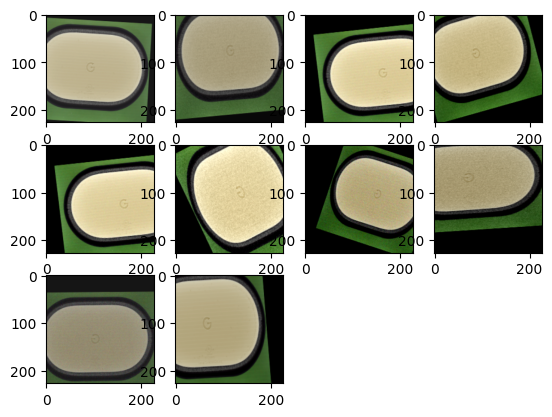

In [158]:
num = 10
col=4
imgs = list(np.random.choice(len(images_aug),num))
for i in range(num):
    plt.subplot(num/col if num%col==0 else int(num/col)+1,col,i+1)
    plt.imshow(images_aug[imgs[i]])

In [159]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC

In [160]:
IMG_SIZE=100
path ="train"

In [161]:
labels = os.listdir(os.path.join(path))
print(labels)
dic = {}
for k,l in enumerate(labels):
    dic[k]=l
dic

['sky', 'charcoal', 'sage', 'chalk', 'sand']


{0: 'sky', 1: 'charcoal', 2: 'sage', 3: 'chalk', 4: 'sand'}

In [162]:
X = []
y = [] #0,1,2,3,4
for k,label in enumerate(labels):
    for i in os.listdir(os.path.join(path,label)):
        img = cv2.imread(os.path.join(path,label,i))
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        X.append(img)
        y.append(k)

In [163]:
X = np.array(X).reshape(len(X),-1)
print(X.shape)
print(y[:10])

(25000, 30000)
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [164]:
# shuffle
X,y = shuffle(X,y)

In [165]:
# norm
X = X/255.0

In [166]:
y = np.array(y)
print(y.shape)

(25000,)


In [167]:
# split
X_train, X_val, y_train, y_val = train_test_split(X,y)

In [168]:
svc = SVC(kernel='linear',gamma='auto')
svc.fit(X_train, y_train)

SVC(gamma='auto', kernel='linear')

In [169]:
y2 = svc.predict(X_val)

In [170]:
# calc accuracy
print("Accuracy on unknown data is",accuracy_score(y_val,y2))

Accuracy on unknown data is 0.99824


In [171]:
print("Accuracy on unknown data is",classification_report(y_val,y2))

Accuracy on unknown data is               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1216
           1       1.00      1.00      1.00      1269
           2       1.00      1.00      1.00      1270
           3       1.00      1.00      1.00      1254
           4       1.00      1.00      1.00      1241

    accuracy                           1.00      6250
   macro avg       1.00      1.00      1.00      6250
weighted avg       1.00      1.00      1.00      6250



Text(0.5, 1.0, 'pred: sage (sage)')

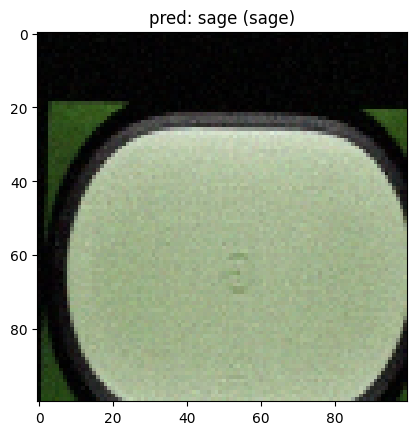

In [172]:
# random test predict
path = 'test'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
i = random.choice(imgs)

img = cv2.imread(os.path.join(path,label,i))
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
img.shape
y= svc.predict(img)
plt.title("pred: " + label +" (" + dic[int(y)] + ")")

Text(0.5, 1.0, 'pred: sky (chalk)')

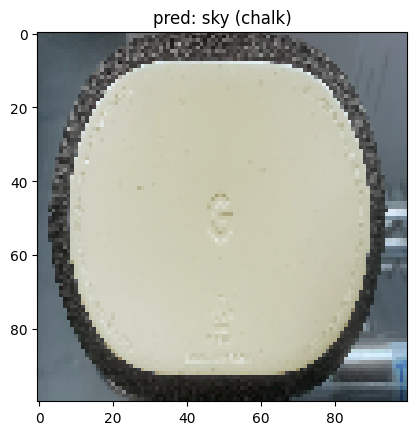

In [173]:
# random test
path = 'gg'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
i = random.choice(imgs)

img = cv2.imread(os.path.join(path,label,i))
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
img.shape
y= svc.predict(img)
plt.title("pred: " + label +" (" + dic[int(y)] + ")")

In [174]:
# save the model to disk
filename = 'classifier_model.sav'
pickle.dump(svc, open(filename, 'wb'))

Text(0.5, 1.0, 'pred: charcoal (charcoal)')

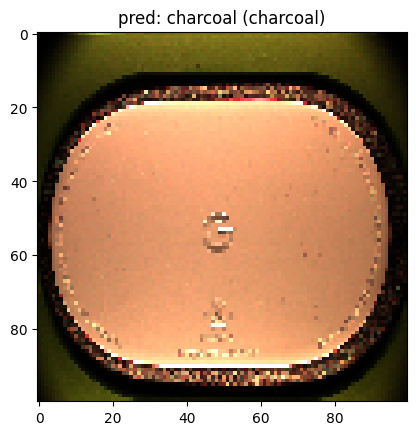

In [200]:
# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))

# random test
path = 'gg'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
i = random.choice(imgs)

img = cv2.imread(os.path.join(path,label,i))
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
img.shape
y= loaded_model.predict(img)
plt.title("pred: " + label +" (" + dic[int(y)] + ")")

# 2.3 CNN

[link](https://www.kaggle.com/code/mohamedelsrogy/notebook08a780470d)

# references

[color-classifier](https://medium.com/analytics-vidhya/building-rgb-color-classifier-part-1-af58e3bcfef7)

[imgaug](https://github.com/aleju/imgaug) [docs](https://imgaug.readthedocs.io/en/latest/)

[color classification](https://github.com/beerboaa/Color-Classification-CNN)

[kaggle color classification](https://www.kaggle.com/datasets/ayanzadeh93/color-classification/code)

[color recognition](https://github.com/ahmetozlu/color_recognition)

[colorNet](https://github.com/dakilaledesma/ColorNet)